<a href="https://colab.research.google.com/github/RafaXzaviero/DATA-SCIENCE/blob/main/clustering_provinsi_indonesia_kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Problem Statement

Saat ini, kita sudah memasuki fase recovery/pasca COVID-19. Sangatlah dibutuhkan pengambilan keputusan
(strategis & operasional) berbasis data sehingga kebijakan
dan keputusan yang dipilih adalah yang paling baik dan
relevan, baik itu oleh pemerintah, industri, dan
masyarakat.<br>

Oleh karena itu, kami ingin mengetahui segmentasi
provinsi-provinsi Indonesia dalam menghadapi
pandemi Covid-19. Segmentasi tersebut dapat
digunakan untuk meningkatkan kesiapan jika pandemi
Covid-19 belum berakhir.


# Data Preprocessing

Tipe dataset yang digunakan adalah Time Series, berawal dari  tanggal 2020-03-01 hingga 2022-09-15. Kita ingin mengklasterkan provinsi sehingga digunakan tanggal terakhir di dataset tersebut dengan Provinsi sebagai index dataset.

In [2]:
df=pd.read_csv("/content/covid_19_indonesia_time_series_all.csv",parse_dates=["Date"],index_col="Province")
df.columns = df.columns.str.replace(' ','_')
df.tail()

,Date,Location_ISO_Code,Location,New_Cases,New_Deaths,New_Recovered,New_Active_Cases,Total_Cases,Total_Deaths,Total_Recovered,...,Latitude,New_Cases_per_Million,Total_Cases_per_Million,New_Deaths_per_Million,Total_Deaths_per_Million,Total_Deaths_per_100rb,Case_Fatality_Rate,Case_Recovered_Rate,Growth_Factor_of_New_Cases,Growth_Factor_of_New_Deaths
Province,,,,,,,,,,,,,,,,,,,,,
Sulawesi Utara,2022-09-15,ID-SA,Sulawesi Utara,37,0,0,37,52770,1213,50997,...,1.259638,14.01,19974.38,0.0,459.14,45.91,2.30%,96.64%,2.85,1.00
Sumatera Barat,2022-09-15,ID-SB,Sumatera Barat,13,0,3,10,104640,2371,102066,...,-0.850253,2.36,18959.11,0.0,429.59,42.96,2.27%,97.54%,6.50,1.00
Sumatera Selatan,2022-09-15,ID-SS,Sumatera Selatan,16,0,1,15,82198,3376,78510,...,-3.216212,1.95,10002.74,0.0,410.83,41.08,4.11%,95.51%,3.20,1.00
Sumatera Utara,2022-09-15,ID-SU,Sumatera Utara,50,0,5,45,158866,3288,154924,...,2.191894,3.36,10680.15,0.0,221.04,22.10,2.07%,97.52%,1.92,1.00
NaN,2022-09-16,IDN,Indonesia,2358,27,2997,-666,6405044,157876,6218708,...,-0.789275,8.89,24153.07,0.1,595.34,59.53,2.46%,97.09%,0.89,1.29


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pengecekan jika terdapat Missing value pada dataset

<Axes: ylabel='Province'>

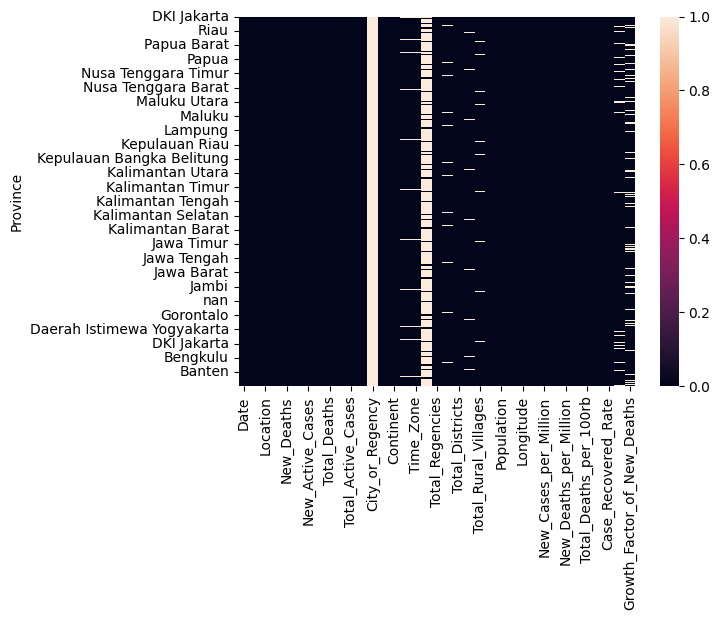

In [4]:
sns.heatmap(df.isna())

In [5]:
df = df[df["Date"] == ("2022-09-15")] #dipilih tanggal terakhir pada dataset
df = df[df.index.notnull()] #drop index yang terdapat missing value
df.head(10)

,Date,Location_ISO_Code,Location,New_Cases,New_Deaths,New_Recovered,New_Active_Cases,Total_Cases,Total_Deaths,Total_Recovered,...,Latitude,New_Cases_per_Million,Total_Cases_per_Million,New_Deaths_per_Million,Total_Deaths_per_Million,Total_Deaths_per_100rb,Case_Fatality_Rate,Case_Recovered_Rate,Growth_Factor_of_New_Cases,Growth_Factor_of_New_Deaths
Province,,,,,,,,,,,,,,,,,,,,,
Aceh,2022-09-15,ID-AC,Aceh,20,0,1,19,44038,2223,41713,...,4.225615,3.81,8392.58,0.00,423.65,42.36,5.05%,94.72%,2.50,1.0
Bali,2022-09-15,ID-BA,Bali,38,1,6,31,166831,4731,161629,...,-8.369472,9.01,39569.32,0.24,1122.11,112.21,2.84%,96.88%,6.33,NaN
Banten,2022-09-15,ID-BT,Banten,240,0,32,208,333875,2950,328482,...,-6.456736,22.38,31138.16,0.00,275.13,27.51,0.88%,98.38%,1.83,1.0
Bengkulu,2022-09-15,ID-BE,Bengkulu,4,0,0,4,29173,522,28617,...,-3.533584,2.00,14589.86,0.00,261.06,26.11,1.79%,98.09%,0.50,1.0
DKI Jakarta,2022-09-15,ID-JK,DKI Jakarta,1116,0,58,1058,1412511,15513,1386134,...,-6.204699,102.89,130231.62,0.00,1430.28,143.03,1.10%,98.13%,0.91,0.0
Daerah Istimewa Yogyakarta,2022-09-15,ID-YO,Daerah Istimewa Yogyakarta,27,0,0,27,224307,5928,217712,...,-7.894502,7.44,61775.29,0.00,1632.60,163.26,2.64%,97.06%,2.25,1.0
Jambi,2022-09-15,ID-JA,Jambi,8,0,0,8,38643,889,37681,...,-1.697698,2.29,11061.85,0.00,254.48,25.45,2.30%,97.51%,8.00,1.0
Jawa Barat,2022-09-15,ID-JB,Jawa Barat,492,0,79,413,1173731,15937,1144358,...,-6.920432,10.89,25989.74,0.00,352.89,35.29,1.36%,97.50%,2.58,1.0
Jawa Tengah,2022-09-15,ID-JT,Jawa Tengah,108,0,2,106,636409,33489,601517,...,-7.259097,2.97,17501.04,0.00,920.94,92.09,5.26%,94.52%,0.88,0.0


# EDA

#### Langkah selanjutnya adalah memilih Feature. Feature yang dipilih adalah feature yang berkaitan dengan Covid.  

Berikut adalah penjelasan lebih lanjut tentang Feature yang tidak dipilih :

&#x2022;New Cases, New Deaths, New Recovered, New Active Cases, New_Cases_per_Million, New_Deaths_per_Million, Growth_Factor_of_New_Cases, dan Growth_Factor_of_New_Deaths tidak dapat digunakan karena hanya merepresentasikan data terbaru dari tanggal yang sudah dipilih

&#x2022;Total_Regencies, Total_Cities, Total_Districts, Total_Urban_Villages, Total_Rural_Villages tidak dipilih karena telah direpresentasikan oleh feature populasi

&#x2022;Area_(km2) tidak dipilih karena telah direpresentasikan oleh feature Population density


Berikut adalah penjelasan lebih lanjut tentang Feature yang dipilih :

&#x2022;Total_Cases, Total_Deaths, Total_Recovered dipilih karena merepresentasikan kumulatif dari semua kasus covid.

&#x2022;Population, Population_Density dipilih karena Populasi dan kepadatan populasi berbanding lurus dengan persebaran kasus Covid.

&#x2022;Total_Cases_per_Million, Total_Deaths_per_Million dipilih karena merepresentasikan Kasus dan Kematian per populasi.

&#x2022;Case_Fatality_Rate, Case_Recovered_Rate dipilih karena merepresentasikan mortalitas kasus covid.


# Feature Engineering

In [6]:
df = df[['Total_Cases','Total_Deaths','Total_Recovered','Population_Density',
        'Population','Total_Cases_per_Million','Total_Deaths_per_Million']] #Membuat dataframe baru dengan feature yang dipilih
df

,Total_Cases,Total_Deaths,Total_Recovered,Population_Density,Population,Total_Cases_per_Million,Total_Deaths_per_Million
Province,,,,,,,
Aceh,44038,2223,41713,90.54,5247257,8392.58,423.65
Bali,166831,4731,161629,729.43,4216171,39569.32,1122.11
Banten,333875,2950,328482,1109.64,10722374,31138.16,275.13
Bengkulu,29173,522,28617,100.38,1999539,14589.86,261.06
DKI Jakarta,1412511,15513,1386134,16334.31,10846145,130231.62,1430.28
Daerah Istimewa Yogyakarta,224307,5928,217712,1158.90,3631015,61775.29,1632.60
Jambi,38643,889,37681,69.79,3493357,11061.85,254.48
Jawa Barat,1173731,15937,1144358,1276.55,45161325,25989.74,352.89
Jawa Tengah,636409,33489,601517,1108.64,36364072,17501.04,920.94


In [7]:
#Menambah kolom feature Fatality Rate dan Recovery Rate
df["Fatality_Rate"] = df.Total_Deaths / df.Total_Cases
df["Recovery_Rate"] = df.Total_Recovered / df.Total_Cases
df.head()

,Total_Cases,Total_Deaths,Total_Recovered,Population_Density,Population,Total_Cases_per_Million,Total_Deaths_per_Million,Fatality_Rate,Recovery_Rate
Province,,,,,,,,,
Aceh,44038,2223,41713,90.54,5247257,8392.58,423.65,0.050479,0.947205
Bali,166831,4731,161629,729.43,4216171,39569.32,1122.11,0.028358,0.968819
Banten,333875,2950,328482,1109.64,10722374,31138.16,275.13,0.008836,0.983847
Bengkulu,29173,522,28617,100.38,1999539,14589.86,261.06,0.017893,0.980941
DKI Jakarta,1412511,15513,1386134,16334.31,10846145,130231.62,1430.28,0.010983,0.981326


<Axes: >

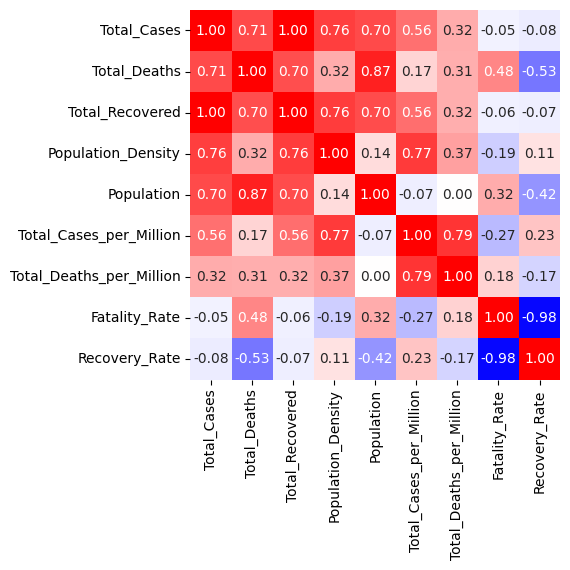

In [8]:
sns.heatmap(df.corr(),cmap="bwr",cbar=False,vmin=-1,vmax=1,annot=True,square=True, fmt =".2f")

### Scaling

Scaling dapat mengontrol variabilitas dataset. Hal ini sangat bermanfaat dalam menghitung jarak antara data pada KMeans Clustering. MinMaxScaling merupakan algoritma yang paling simple.

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [10]:
#Scaling dataset dengan MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(df)
scaled_df = pd.DataFrame(scaler.transform(df),columns= df.columns)
scaled_df

,Total_Cases,Total_Deaths,Total_Recovered,Population_Density,Population,Total_Cases_per_Million,Total_Deaths_per_Million,Fatality_Rate,Recovery_Rate
0,0.021062,0.058083,0.020021,0.005020,0.103315,0.012281,0.193480,0.893271,0.133663
1,0.108902,0.133639,0.107430,0.044154,0.080151,0.265023,0.659439,0.418764,0.644682
2,0.228397,0.079984,0.229053,0.067443,0.226316,0.196674,0.094398,0.000000,1.000000
3,0.010428,0.006839,0.010475,0.005622,0.030354,0.062521,0.085012,0.194290,0.931294
4,1.000000,0.458456,1.000000,1.000000,0.229096,1.000000,0.865027,0.046053,0.940394
5,0.150018,0.169699,0.148310,0.070460,0.067005,0.445041,1.000000,0.377365,0.686757
6,0.017203,0.017895,0.017082,0.003749,0.063913,0.033920,0.080622,0.303949,0.793318
7,0.829189,0.471230,0.823764,0.077666,1.000000,0.154937,0.146274,0.101727,0.790226
8,0.444815,1.000000,0.428075,0.067381,0.802366,0.086121,0.525234,0.939233,0.085642
9,0.419875,0.948033,0.404374,0.051342,0.894810,0.064716,0.434345,0.943141,0.102878


# Dimensionality Reduction

DimensionalIity Reduction membantu kita untuk memvisualisasikan dataset. Jumlah feature yang dipilih dalam dataset ini adalah 9. Kita, sebagai makhluk 3 Dimensi, tidak dapat memvisualisasikan 9 Dimensi, sehingga diperlukan penurunan dimensi. Dalam kasus ini, kami menurunkan ke 3 dimensi.

### PCA

In [11]:
from sklearn.decomposition import PCA

In [12]:
pca = PCA(n_components = 3,random_state = 42)
pca_data= pd.DataFrame(pca.fit_transform(scaled_df), columns=(["PC1","PC2", "PC3"]))
pca_data.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,32.0,-3.122502e-17,0.491700,-0.475742,-0.335344,-0.153785,0.106124,1.292272
PC2,32.0,-1.387779e-17,0.407008,-0.854254,-0.113292,0.022829,0.153741,1.423759
PC3,32.0,-3.122502e-17,0.316095,-0.897468,-0.203055,-0.081340,0.143035,0.623915


In [13]:
import plotly.express as px
x =pca_data["PC1"]
y =pca_data["PC2"]
z =pca_data["PC3"]
fig = px.scatter_3d(pca_data, x, y, z,color=df.index)
fig.show()


# Modelling / Clustering

Salah satu kekurangan dari Algoritma Clustering Kmeans adalah kita harus mengetahui jumlah cluster yang diinginkan.  Maka dari itu, sudah terdapat metode yang cukup terkenal untuk mencari jumlah cluster yang optimal, yaitu Elbow Method.
Elbow Method ini didapat dari membuat graph antara jumlah cluster dan score WCSS atau Within Cluster Sum of Squares.

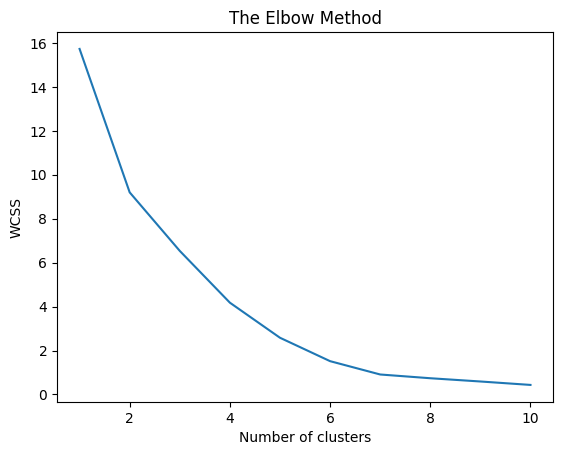

In [14]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters= i,
    init = 'k-means++', max_iter= 300, n_init= 10)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

### Evaluasi Jumlah K dengan Silhouette Score

Untuk mengatasi subjektivitas Elbow Method, kita akan menggunakan Silhouette Score. Metrik ini mengukur seberapa mirip sebuah objek dengan klusternya sendiri (kohesi) dibandingkan dengan kluster tetangga (pemisahan). Nilai Silhouette Score berkisar dari -1 hingga 1, di mana nilai yang lebih tinggi menunjukkan kluster yang lebih baik (lebih padat dan terpisah).


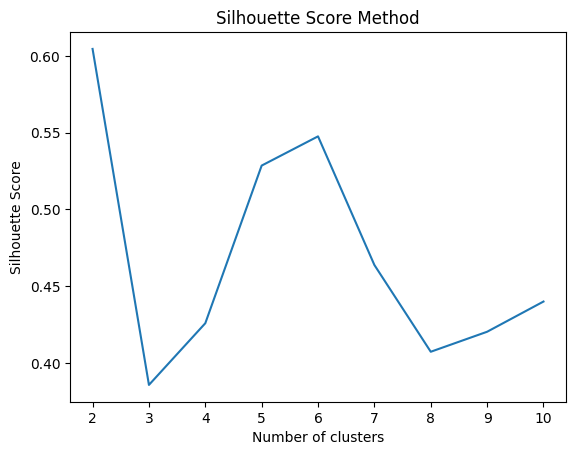

Optimal number of clusters based on Silhouette Score: 2


In [35]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
# Iterate from 2 to 10 clusters (Silhouette Score is not defined for n_clusters=1)
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(pca_data)
    score = silhouette_score(pca_data, kmeans.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Find the optimal number of clusters based on the highest Silhouette Score
optimal_k_silhouette = range(2, 11)[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k_silhouette}")


Jumlah cluster yang optimum dapat ditentukan dengan mencari "Elbow" atau Siku pada graph. Pada kasus ini, dipilih jumlah cluster k = 5.

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42) #n_clusters merupakan Jumlah cluster yang dipilih
                                              #dan random_state digunakan untuk mengontrol ke-random-an saat rerun kernel.
labels = kmeans.fit_predict(pca_data)
np.unique(labels)

array([0, 1, 2, 3, 4], dtype=int32)

In [16]:
x =pca_data["PC1"]
y =pca_data["PC2"]
z =pca_data["PC3"]
fig = px.scatter_3d(pca_data, x, y, z,color=labels)
fig.show()


# Visualisasi dan Komparasi Cluster

In [17]:
df["Clusters"] = labels #append column cluster pada dataframe awal

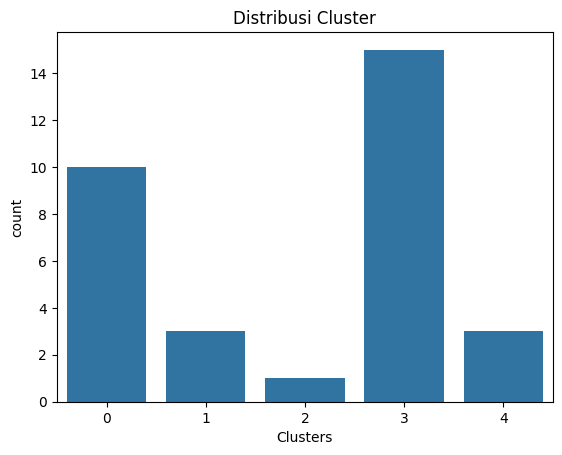

In [18]:
pl = sns.countplot(x=df["Clusters"])
pl.set_title("Distribusi Cluster")
plt.show()

### Anggota Cluster

In [19]:
Cluster1 = df[df['Clusters']==0]
Cluster2 = df[df['Clusters']==1]
Cluster3 = df[df['Clusters']==2]
Cluster4 = df[df['Clusters']==3]
Cluster5 = df[df['Clusters']==4]

In [20]:
list(Cluster1.index)

['Bali',
 'Daerah Istimewa Yogyakarta',
 'Kalimantan Selatan',
 'Kalimantan Tengah',
 'Kalimantan Timur',
 'Kalimantan Utara',
 'Kepulauan Bangka Belitung',
 'Kepulauan Riau',
 'Riau',
 'Sulawesi Tengah']

In [21]:
list(Cluster2.index)

['Jawa Barat', 'Jawa Tengah', 'Jawa Timur']

In [22]:
list(Cluster3.index)

['DKI Jakarta']

In [23]:
list(Cluster4.index)

['Banten',
 'Bengkulu',
 'Jambi',
 'Kalimantan Barat',
 'Maluku',
 'Maluku Utara',
 'Nusa Tenggara Barat',
 'Nusa Tenggara Timur',
 'Papua',
 'Papua Barat',
 'Sulawesi Selatan',
 'Sulawesi Tenggara',
 'Sulawesi Utara',
 'Sumatera Barat',
 'Sumatera Utara']

In [24]:
list(Cluster5.index)

['Aceh', 'Lampung', 'Sumatera Selatan']

### Karakteristik Kluster

In [25]:
df_mean = pd.concat([pd.DataFrame(df.mean().drop('Clusters'), columns=['mean']),
                   df.groupby('Clusters').mean().T], axis=1)
df_dev_rel = df_mean.apply(lambda x: round((x-x['mean'])/x['mean'],2)*100, axis = 1)
df_dev_rel.drop(columns=['mean'], inplace=True)
df_mean.drop(columns=['mean'], inplace=True)

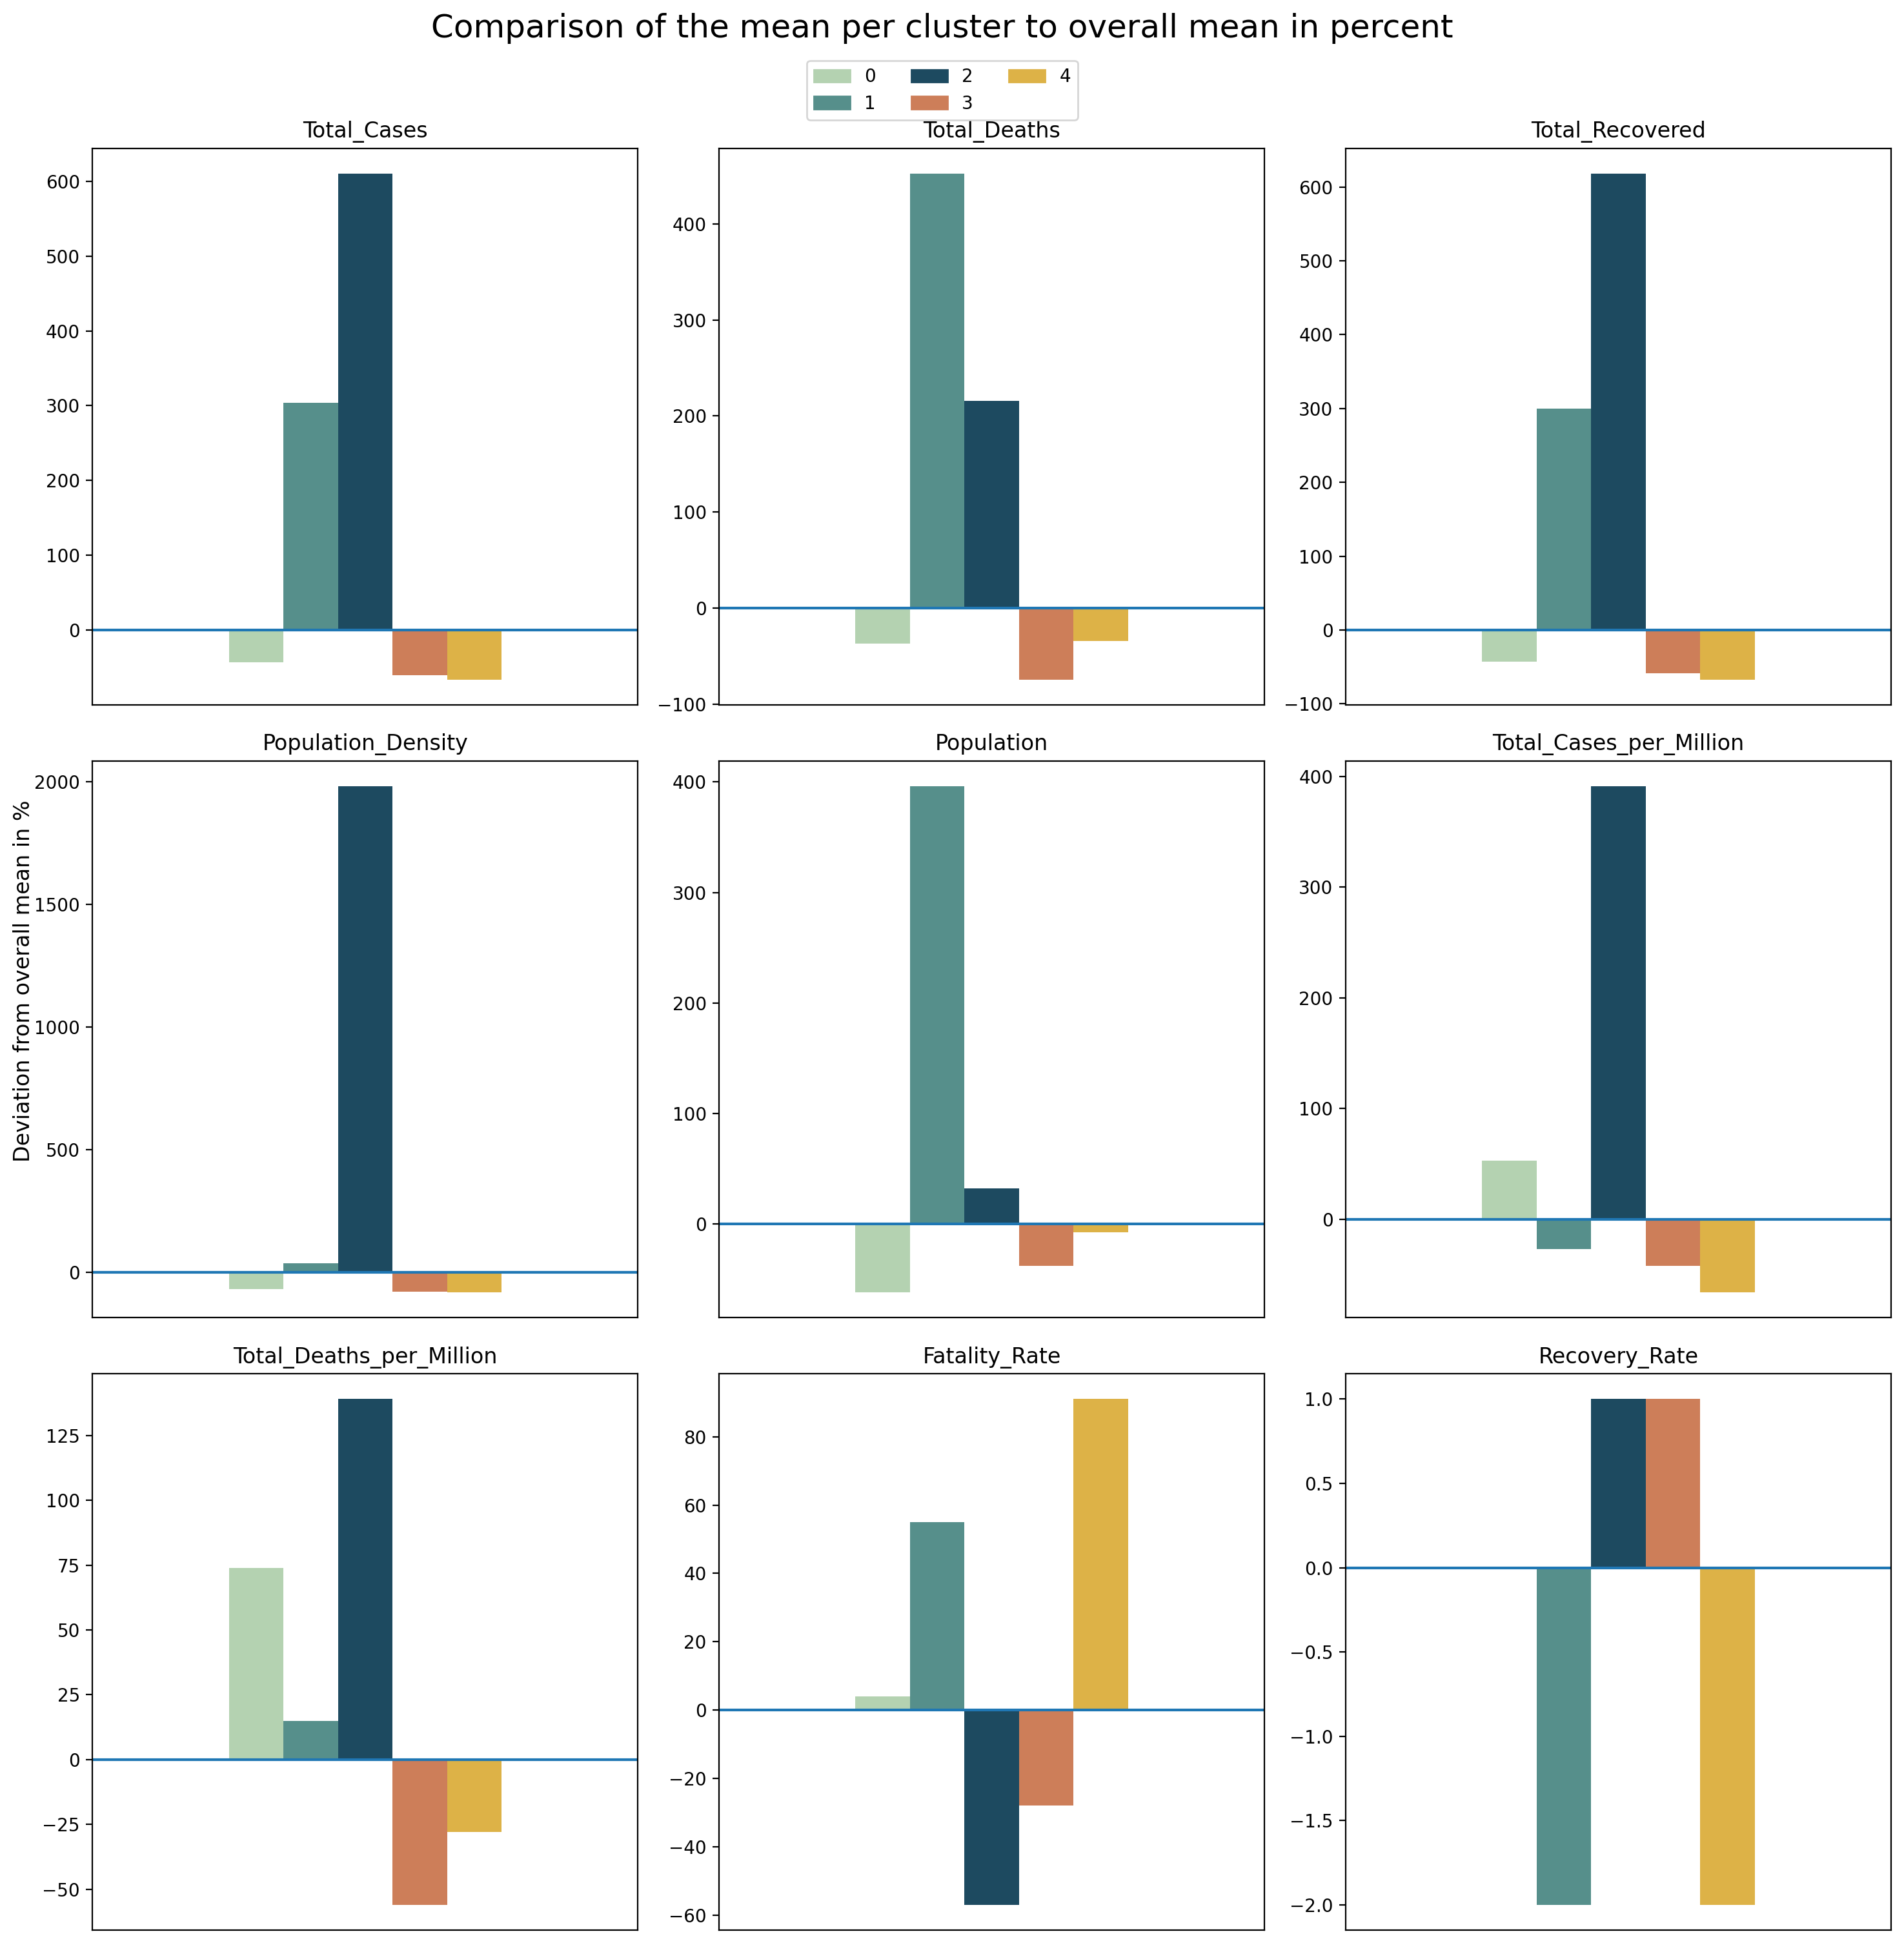

In [26]:
cluster_colors = ['#b4d2b1', '#568f8b', '#1d4a60', '#cd7e59', '#ddb247', '#d15252']
import matplotlib.patches as mpatches
def cluster_comparison_bar(df_comparison, colors, deviation=True ,title="Cluster results"):

    features = df_comparison.index
    ncols = 3
    nrows = len(features) // ncols + (len(features) % ncols > 0)
    fig = plt.figure(figsize=(15,15), dpi=200)
    for n, feature in enumerate(features):
        # create chart
        ax = plt.subplot(nrows, ncols, n + 1)
        df_comparison[df_comparison.index==feature].plot(kind='bar', ax=ax, title=feature,
                                                             color=colors[0:df.Clusters.nunique()],
                                                             legend=False
                                                            )
        plt.axhline(y=0)
        x_axis = ax.axes.get_xaxis()
        x_axis.set_visible(False)

    c_labels = df_comparison.columns.to_list()
    c_colors = colors[0:3]
    mpats = [mpatches.Patch(color=c, label=l) for c,l in list(zip(colors[0:df.Clusters.nunique()],
                                                                  df_comparison.columns.to_list()))]

    fig.legend(handles=mpats,
               ncol=ncols,
               loc="upper center",
               fancybox=True,
               bbox_to_anchor=(0.5, 0.98)
              )
    axes = fig.get_axes()

    fig.suptitle(title, fontsize=18, y=1)
    fig.supylabel('Deviation from overall mean in %')
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

cluster_comparison_bar(df_dev_rel, cluster_colors, title="Comparison of the mean per cluster to overall mean in percent")

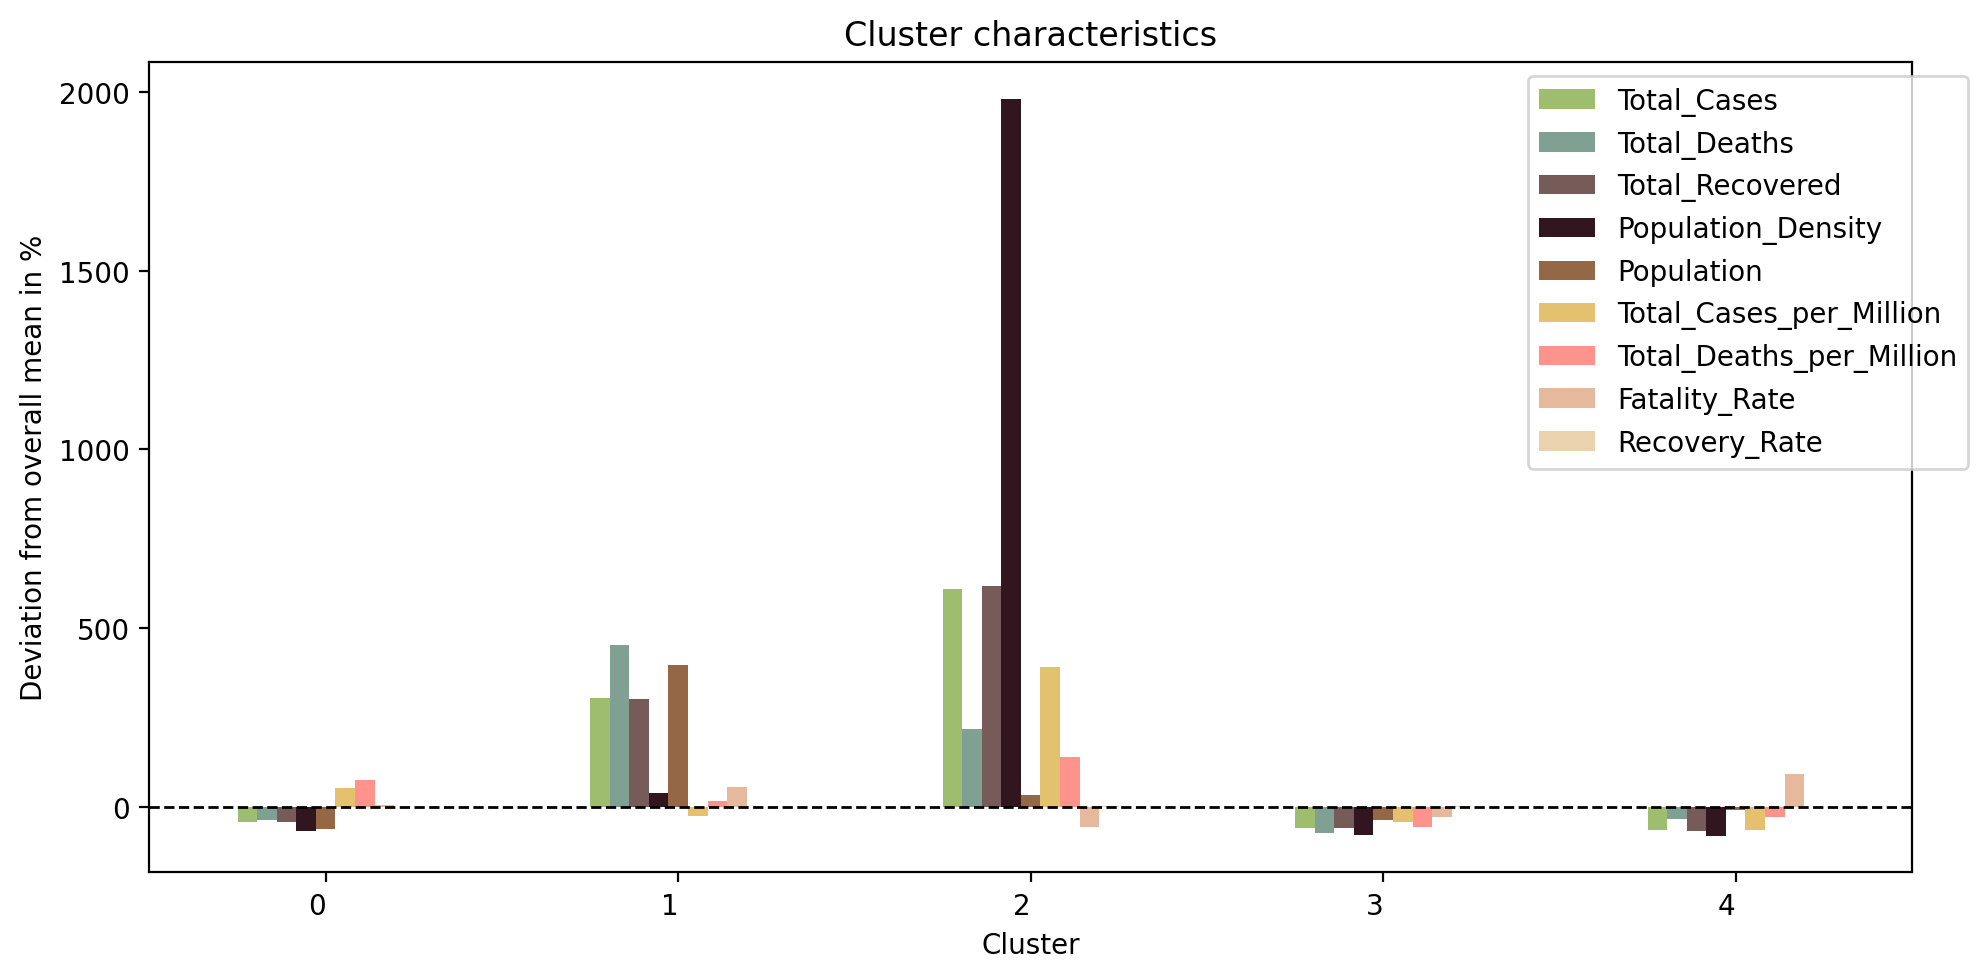

In [27]:
colors = ['#9EBD6E','#81a094','#775b59','#32161f', '#946846', '#E3C16F', '#fe938c', '#E6B89C','#EAD2AC',
          '#DE9E36', '#4281A4','#37323E','#95818D'
         ]

fig = plt.figure(figsize=(10,5), dpi=200)
df_dev_rel.T.plot(kind='bar',
                       ax=fig.add_subplot(),
                       title="Cluster characteristics",
                       color=colors,
                       xlabel="Cluster",
                       ylabel="Deviation from overall mean in %"
                      )
plt.axhline(y=0, linewidth=1, ls='--', color='black')
plt.legend(bbox_to_anchor=(1.04,1))
fig.autofmt_xdate(rotation=0)
plt.tight_layout()
plt.show()

# Kesimpulan dan Rekomendasi

Cluster 1 (Bali, Daerah Istimewa Yogyakarta, Kalimantan Timur,  Kalimantan Utara, Kepulauan Bangka Belitung, Kepulauan Riau) :
Meskipun klaster ini memiliki jumlah kasus yang rendah, tetapi hal ini dapat disebabkan oleh karena populasi yang juga rendah. Jika ditinjau dari jumlah kasus per populasi klaster ini dapat dikatakan cukup tinggi begitu jumlah kematian per populasi. Sehingga dapat disimpulkan bahwa provinsi pada klaster ini upaya preventif dan penanganan Covid-19 masih perlu ditingkatkan


Cluster 2 (Banten, Bengkulu, Jambi, Kalimantan Barat, Kalimantan Selatan,  Kalimantan Tengah, Maluku, Maluku Utara, Nusa Tenggara Barat, Nusa Tenggara Timur, Papua, Papua Barat, Riau, Sulawesi Selatan, Sulawesi Tengah, Sulawesi Tenggara,  Sulawesi Utara, Sumatera Barat, Sumatera Utara) :
Pada klaster ini dapat dilihat bahwa memiliki jumlah kasus per populasi yang rendah dan jumlah kematian per populasi terendah. Sehingga dapat disimpulkan bahwa provinsi pada klaster ini sudah memiliki upaya yang baik dalam tindakan preventif dan penanganan Covid-19.

Cluster 3 (Jawa Tengah, Jawa Timur) :
Klaster ini merupakan klaster dengan populasi tertinggi dan kepadatan populasi yang juga diatas rata-rata. Jumlah kasus pada klaster ini cukup tinggi tetapi jika dilihat dari jumlah kasus per populasi berada di salah satu yang terendah. Klaster  ini memiliki tingkat kematiannya tertinggi dan juga tingkat pemulihan terendah. Sehingga dapat disimpulkan provinsi pada klaster ini perlu meningkatkan upaya penanganan pasien Covid-19.

Cluster 4 (DKI Jakarta, Jawa Barat) :
Klaster ini merupakan klaster dengan kepadatan populasi tertinggi. Klaster ini memiliki total kasus dan total kasus per populasi tertinggi. Jika kita meninjau dari tingkat pemulihan dan tingkat kematian, klaster ini memiliki tingkat pemulihan tertinggi dan tingkat kematian terendah dari klaster lainnya. Sehingga dapat disimpulkan bahwa upaya penanganan sudah cukup baik tetapi upaya preventif masih perlu ditingkatkan lebih.

Cluster 5 (Aceh, Lampung, Sumatera Selatan) :
Klaster ini adalah salah satu klaster dengan total kasus terendah dan total kasus per populasi terendah, Tetapi, pada klaster ini juga memilik tingkat pemulihan yang rendah dan tingkat kematian yang tinggi. Oleh karena itu, dapat disimpulkan bahwa penanganan terhadap pasien COVID-19 perlu ditingkatkan kembali.

## Ekperimen GAP KNN

Gap: K-Means "Buta" terhadap Lokasi Geografis K-Means standar murni menggunakan jarak matematis (Euclidean distance) pada fitur numerik. Algoritma ini tidak tahu bahwa Jawa Barat dan Jawa Tengah itu bersebelahan. Padahal, dalam ekonomi wilayah, provinsi yang bertetangga sering kali memiliki efek limpahan (spillover effect) satu sama lain.

In [28]:
!pip install geopandas libpysal spopt

### 1. Load GeoJSON for Indonesian Provinces
To perform spatial clustering, we need the geometric shapes of the provinces. We will use a public GeoJSON source for Indonesia provinces.

In [29]:
import geopandas as gpd
import libpysal
from spopt.region import Skater

# Using an alternative reliable GeoJSON source for Indonesian Provinces
url = "https://raw.githubusercontent.com/superpikar/indonesia-geojson/master/indonesia-province.json"
world = gpd.read_file(url)

# Basic cleaning of province names to ensure better matching
world['propinsi'] = world['Propinsi'].str.title()
# Ensure the original df index is titled consistently
df.index = df.index.astype(str).str.title()

display(world[['propinsi', 'geometry']].head())

,propinsi,geometry
0,Irian Jaya Timur,"MULTIPOLYGON (((137.91666 -1.49852, 137.8926 -..."
1,Nusatenggara Barat,"MULTIPOLYGON (((117.6272 -8.5064, 117.6263 -8...."
2,Gorontalo,"MULTIPOLYGON (((122.18814 1.0453, 122.18883 1...."
3,Sulawesi Tenggara,"MULTIPOLYGON (((120.98423 -2.83534, 120.98502 ..."
4,Daerah Istimewa Yogyakarta,"POLYGON ((110.01183 -7.8869, 110.0133 -7.88587..."


### 2. Merge COVID Data with Spatial Data
We need to join our scaled features (`scaled_df`) with the GeoDataFrame.

In [30]:
# Merge COVID Data with Spatial Data
df_spatial = world.merge(df.reset_index(), left_on='propinsi', right_on='Province')

# Features to use for spatial clustering
features = ['Total_Cases', 'Total_Deaths', 'Total_Recovered', 'Population_Density', 'Population', 'Total_Cases_per_Million', 'Total_Deaths_per_Million', 'Fatality_Rate', 'Recovery_Rate']

# Calculate Spatial Weights (Adjacency Matrix)
weights = libpysal.weights.Queen.from_dataframe(df_spatial)

# Handle islands/isolates by connecting to nearest neighbors using a union with KNN
if weights.islands:
    print(f"Islands detected: {len(weights.islands)}. Connecting to nearest neighbors.")
    knn = libpysal.weights.KNN.from_dataframe(df_spatial, k=1)
    weights = libpysal.weights.w_union(weights, knn)

/tmp/ipykernel_4766/1180256182.py:8: FutureWarning:

`use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning



Islands detected: 5. Connecting to nearest neighbors.


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning:

The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 5 islands with ids: 4, 5, 11, 12, 16.

/usr/local/lib/python3.12/dist-packages/libpysal/weights/distance.py:153: UserWarning:

The weights matrix is not fully connected: 
 There are 7 disconnected components.

/usr/local/lib/python3.12/dist-packages/libpysal/weights/set_operations.py:80: UserWarning:

The weights matrix is not fully connected: 
 There are 5 disconnected components.



### 3. Apply Spatially Constrained Clustering (SKATER)
The SKATER algorithm creates clusters that are geographically contiguous and internally homogeneous.

/tmp/ipykernel_4766/3768921086.py:4: OptimizeWarning:

By default, the graph is disconnected! Increasing `n_clusters` from 5 to 10 in order to account for islands.



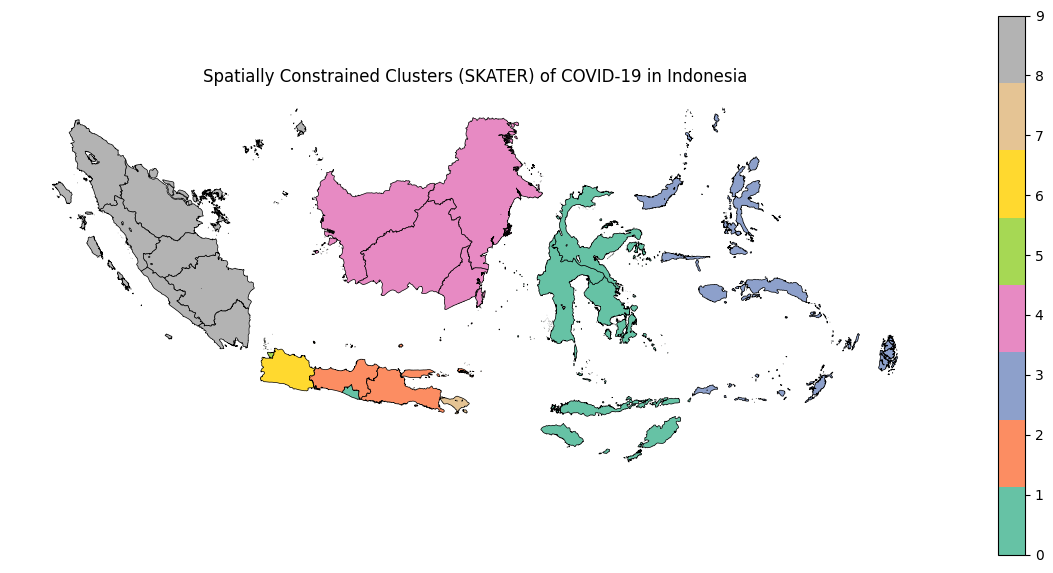

In [31]:
# Apply Spatially Constrained Clustering (SKATER)
# spopt Skater requires: (gdf, w, attrs_name, n_clusters)
model = Skater(df_spatial, weights, attrs_name=features, n_clusters=5)
model.solve()

df_spatial['spatial_cluster'] = model.labels_

# Visualize results on a map
fig, ax = plt.subplots(1, 1, figsize=(15, 7))
df_spatial.plot(column='spatial_cluster', ax=ax, legend=True, cmap='Set2', edgecolor='black', linewidth=0.5)
plt.title("Spatially Constrained Clusters (SKATER) of COVID-19 in Indonesia")
plt.axis('off')
plt.show()

## Gap: Sensitivitas Tinggi Terhadap Outlier (Pencilan)
K-Means sangat sensitif terhadap outlier. Dalam konteks data Indonesia, provinsi seperti DKI Jakarta (karena PDRB dan infrastruktur yang jauh lebih tinggi) atau Papua (karena tantangan geografis yang unik) sering menjadi outlier. Kehadiran mereka bisa "menarik" titik tengah (centroid) kluster dan membuat pengelompokan provinsi lain menjadi kurang akurat.

In [32]:
!pip install "numpy<2" scikit-learn-extra
# Note: You might need to click 'Restart Session' in the output below for the changes to take effect.

### Eksperimen 2a: K-Means Tanpa Outlier (DKI Jakarta)
Kita akan menghapus DKI Jakarta dari proses clustering untuk melihat apakah persebaran kluster provinsi lain menjadi lebih seimbang.

In [33]:
# Menghapus DKI Jakarta
df_no_jakarta = df[df.index != 'Dki Jakarta']
scaled_df_no_jkt = scaled_df.drop(index=4) # Index 4 adalah DKI Jakarta di scaled_df

# Re-run PCA untuk data tanpa Jakarta
pca_no_jkt = PCA(n_components=3, random_state=42)
pca_data_no_jkt = pd.DataFrame(pca_no_jkt.fit_transform(scaled_df_no_jkt), columns=(["PC1","PC2", "PC3"]))

# Re-run K-Means (k=4 karena Jakarta sudah keluar)
kmeans_no_jkt = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_no_jkt = kmeans_no_jkt.fit_predict(pca_data_no_jkt)

# Visualisasi
fig = px.scatter_3d(pca_data_no_jkt, x="PC1", y="PC2", z="PC3", color=labels_no_jkt.astype(str),
                     hover_name=df_no_jakarta.index, title="K-Means Clustering (Tanpa DKI Jakarta)")
fig.show()

### Eksperimen 2b: K-Medoids (PAM) - Robust Clustering
K-Medoids menggunakan objek nyata sebagai pusat kluster, sehingga tidak terlalu terpengaruh oleh nilai ekstrem seperti K-Means.

In [34]:
import numpy as np
from sklearn_extra.cluster import KMedoids

# Using the full data (including Jakarta) to see the robustness of K-Medoids
kmedoids = KMedoids(n_clusters=5, random_state=42)
labels_kmedoids = kmedoids.fit_predict(pca_data)

# Visualize comparison
df['KMedoids_Labels'] = labels_kmedoids
fig = px.scatter_3d(pca_data, x="PC1", y="PC2", z="PC3", color=labels_kmedoids.astype(str),
                     hover_name=df.index, title="K-Medoids Clustering (Robust to Outliers)")
fig.show()

## Kesimpulan Akhir Eksperimen

Setelah melakukan serangkaian eksperimen klustering, beberapa poin penting dapat ditarik:

1.  **Evaluasi Jumlah Kluster (K)**: Awalnya, metode Elbow mengusulkan 5 kluster. Namun, analisis **Silhouette Score** yang lebih objektif menunjukkan bahwa **2 kluster** mungkin merupakan pilihan yang lebih kohesif dan terpisah secara optimal. Ini menyoroti pentingnya menggunakan beberapa metrik validasi internal untuk menentukan `K` dan tidak hanya bergantung pada metode visual yang subjektif.

2.  **Pentingnya Konteks Spasial**: Eksperimen **Spatially Constrained Clustering (SKATER)** menunjukkan bahwa dengan mempertimbangkan kedekatan geografis, kita bisa mendapatkan segmentasi provinsi yang berbeda dan berpotensi lebih bermakna. Kluster yang dihasilkan oleh SKATER mencerminkan pola regional yang tidak terlihat oleh K-Means standar, yang 'buta' terhadap lokasi.

3.  **Robustness terhadap Outlier**: Percobaan dengan menghapus DKI Jakarta dari **K-Means** dan menerapkan **K-Medoids** membuktikan bagaimana outlier dapat secara signifikan memengaruhi hasil klustering. K-Medoids, sebagai metode yang lebih robust, cenderung memberikan pusat kluster yang lebih representatif di tengah kehadiran pencilan, menawarkan alternatif yang lebih stabil untuk segmentasi.

Secara keseluruhan, pemahaman tentang segmentasi provinsi dalam menghadapi pandemi COVID-19 menjadi jauh lebih kaya dengan mempertimbangkan tidak hanya statistik kasus, tetapi juga faktor geografis dan karakteristik data itu sendiri. Pemilihan metode klustering yang tepat dan validasi yang komprehensif adalah kunci untuk mendapatkan wawasan yang akurat dan dapat ditindaklanjuti.